# LFR Training — Metrics & Latent Space Visualization

This notebook visualises:
1. **Training curves** — train/val loss over 400 epochs (from CSVLogger)
2. **t-SNE of the latent space** — 2-D projection of backbone embeddings on the test set, coloured by activity class

In [1]:
import sys
from pathlib import Path

current_dir = Path.cwd()
project_root = current_dir.parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.manifold import TSNE

from minerva.data.readers.csv_reader import CSVReader
from minerva.data.datasets.base import SimpleDataset
from minerva.models.nets.time_series.resnet import ResNetSE1D_5
from minerva.transforms import Reshape, CastTo, TransformPipeline

ROOT = project_root
ACTIVITY_LABELS = {0: 'Sit', 1: 'Stand', 2: 'Walk', 3: 'Stair-up', 4: 'Stair-down', 5: 'Run'}
COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860']

## 1 — Training curves

In [2]:
# Find the latest CSVLogger version directory
log_base = ROOT / 'logs' / 'lfr'
version_dirs = sorted(log_base.glob('version_*'))
assert version_dirs, f'No log versions found under {log_base}. Run train_lfr.py first.'

metrics_path = version_dirs[-1] / 'metrics.csv'
print(f'Loading metrics from: {metrics_path}')

metrics = pd.read_csv(metrics_path)
print(metrics.head())
print('Columns:', metrics.columns.tolist())
print('Shape:', metrics.shape)

Loading metrics from: /home/miguel/fed-har/logs/lfr/version_0/metrics.csv
   epoch  step  train_loss   val_loss
0      0    55         NaN  22.572693
1      0    55   18.291914        NaN
2      1   111         NaN  22.484039
3      1   111   15.794261        NaN
4      2   167         NaN  21.579338
Columns: ['epoch', 'step', 'train_loss', 'val_loss']
Shape: (200, 4)


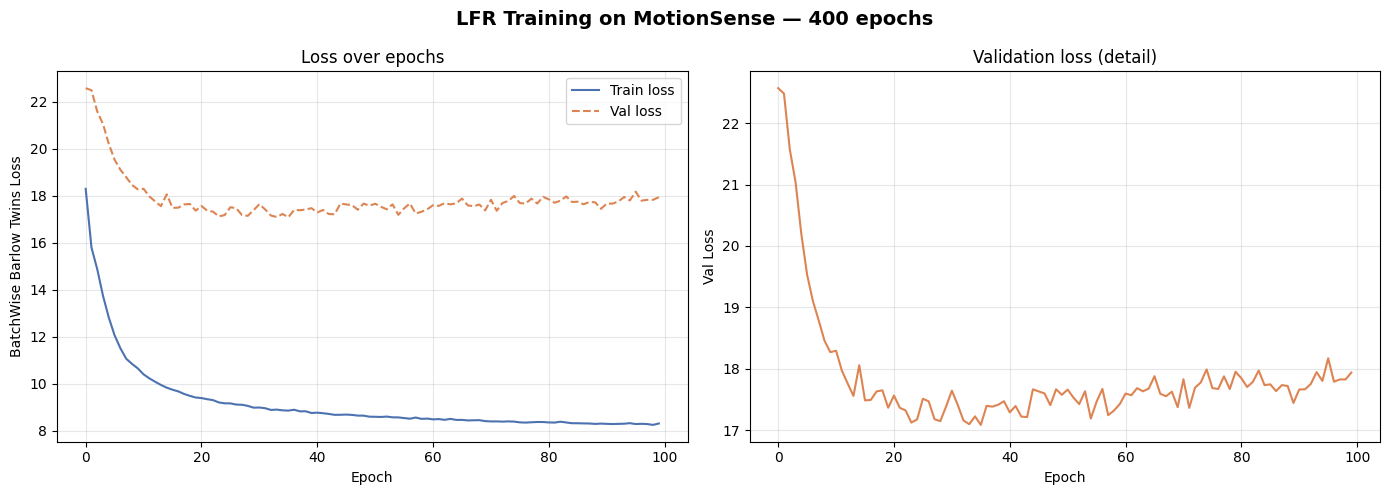

Best val_loss: 17.0834 at epoch 35


In [3]:
# CSVLogger writes one row per log call; separate train and val rows by epoch
train_metrics = metrics.dropna(subset=['train_loss'])[['epoch', 'train_loss']].drop_duplicates('epoch')
val_metrics   = metrics.dropna(subset=['val_loss'])[['epoch', 'val_loss']].drop_duplicates('epoch')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LFR Training on MotionSense — 400 epochs', fontsize=14, fontweight='bold')

# ── Left: both curves on the same axis ──────────────────────────────────
ax = axes[0]
ax.plot(train_metrics['epoch'], train_metrics['train_loss'], label='Train loss', color='#4C72B0', linewidth=1.5)
ax.plot(val_metrics['epoch'],   val_metrics['val_loss'],   label='Val loss',   color='#DD8452', linewidth=1.5, linestyle='--')
ax.set_xlabel('Epoch')
ax.set_ylabel('BatchWise Barlow Twins Loss')
ax.set_title('Loss over epochs')
ax.legend()
ax.grid(alpha=0.3)

# ── Right: val loss only (zoomed to see convergence detail) ──────────────
ax = axes[1]
ax.plot(val_metrics['epoch'], val_metrics['val_loss'], color='#DD8452', linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Val Loss')
ax.set_title('Validation loss (detail)')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / 'results' / 'lfr_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Best val_loss: {val_metrics["val_loss"].min():.4f} at epoch {val_metrics.loc[val_metrics["val_loss"].idxmin(), "epoch"]}')

## 2 — Latent space: t-SNE

In [4]:
backbone_path = ROOT / 'checkpoints' / 'lfr' / 'lfr_backbone.pt'
assert backbone_path.exists(), f'Backbone not found at {backbone_path}'

resnet = ResNetSE1D_5(input_shape=(6, 60), num_classes=6)
resnet.backbone.load_state_dict(torch.load(backbone_path, weights_only=True))
backbone = resnet.backbone.eval()
print('Backbone loaded.')

Backbone loaded.


In [5]:
# Build test dataset
data_dir = ROOT / 'datasets' / 'DAGHAR' / 'standardized_view' / 'MotionSense'
SENSOR_COLS = ['accel-x-*', 'accel-y-*', 'accel-z-*', 'gyro-x-*', 'gyro-y-*', 'gyro-z-*']

test_ds = SimpleDataset(
    readers=[
        CSVReader(path=data_dir / 'test.csv', columns_to_select=SENSOR_COLS),
        CSVReader(path=data_dir / 'test.csv', columns_to_select='standard activity code', cast_to='int64'),
    ],
    transforms=[
        TransformPipeline([Reshape((6, 60)), CastTo('float32')]),
        CastTo('int64'),
    ],
)

# Extract embeddings in batches
embeddings, labels = [], []
device = 'cuda' if torch.cuda.is_available() else 'cpu'
backbone = backbone.to(device)

batch_size = 128
with torch.no_grad():
    for i in range(0, len(test_ds), batch_size):
        batch = [test_ds[j] for j in range(i, min(i + batch_size, len(test_ds)))]
        x_batch = torch.stack([s[0] for s in batch]).to(device)
        y_batch = [s[1].item() for s in batch]
        z = backbone(x_batch)
        embeddings.append(z.cpu().numpy())
        labels.extend(y_batch)

embeddings = np.vstack(embeddings)
labels = np.array(labels)
print(f'Embeddings shape: {embeddings.shape}  |  unique labels: {np.unique(labels)}')

TypeError: expected Tensor as element 0 in argument 0, but got numpy.ndarray

In [ ]:
print('Running t-SNE …')
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42, verbose=1)
embeddings_2d = tsne.fit_transform(embeddings)
print('t-SNE done.')

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

for cls_id, cls_name in ACTIVITY_LABELS.items():
    mask = labels == cls_id
    ax.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        label=cls_name,
        color=COLORS[cls_id],
        s=18,
        alpha=0.75,
        edgecolors='none',
    )

ax.set_title('t-SNE of LFR backbone embeddings — MotionSense test set', fontsize=13, fontweight='bold')
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
ax.legend(title='Activity', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(ROOT / 'results' / 'lfr_tsne_latent_space.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Compare with random (untrained) backbone ────────────────────────────
print('Extracting embeddings with RANDOM backbone …')
random_resnet = ResNetSE1D_5(input_shape=(6, 60), num_classes=6)
random_backbone = random_resnet.backbone.eval().to(device)

rand_embeddings = []
with torch.no_grad():
    for i in range(0, len(test_ds), batch_size):
        batch = [test_ds[j] for j in range(i, min(i + batch_size, len(test_ds)))]
        x_batch = torch.stack([s[0] for s in batch]).to(device)
        z = random_backbone(x_batch)
        rand_embeddings.append(z.cpu().numpy())

rand_embeddings = np.vstack(rand_embeddings)

print('Running t-SNE on random backbone embeddings …')
rand_embeddings_2d = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42).fit_transform(rand_embeddings)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('t-SNE: LFR pretrained vs Random backbone', fontsize=14, fontweight='bold')

for ax, emb_2d, title in [
    (axes[0], embeddings_2d,      'LFR pretrained backbone'),
    (axes[1], rand_embeddings_2d, 'Random (untrained) backbone'),
]:
    for cls_id, cls_name in ACTIVITY_LABELS.items():
        mask = labels == cls_id
        ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                   label=cls_name, color=COLORS[cls_id], s=18, alpha=0.75, edgecolors='none')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('t-SNE dim 1')
    ax.set_ylabel('t-SNE dim 2')
    ax.legend(title='Activity', bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(ROOT / 'results' / 'lfr_tsne_comparison.png', dpi=150, bbox_inches='tight')
plt.show()